## BUA CEMENT STOCK PRICE PREDICTION

After the performance of FCMB monthly data. Let us apply the same strategy with BUA CEMENT with less data points.

In [ ]:
import pandas as pd

bua=pd.read_csv('../stock_data/BUACEMENT.csv')
bua

,id,symbol,trade_date,open_price,high_price,low_price,close_price,volume,created_at
0,113604,BUACEMENT,2020-01-09,38.45,NaN,NaN,38.45,12922043,2026-04-08T03:23:48.760691+00:00
1,113707,BUACEMENT,2020-01-10,41.00,NaN,NaN,41.00,8198646,2026-04-08T03:23:51.312987+00:00
2,113810,BUACEMENT,2020-01-13,39.00,NaN,NaN,39.00,2535597,2026-04-08T03:23:55.704331+00:00
3,113913,BUACEMENT,2020-01-14,38.95,NaN,NaN,38.95,5989966,2026-04-08T03:23:58.044369+00:00
4,114016,BUACEMENT,2020-01-15,38.00,NaN,NaN,38.00,12562001,2026-04-08T03:24:00.340453+00:00
...,...,...,...,...,...,...,...,...,...
1536,298032,BUACEMENT,2026-07-13,306.20,NaN,NaN,306.20,655992,2026-07-13T15:10:02.995074+00:00
1537,298470,BUACEMENT,2026-07-14,306.20,NaN,NaN,306.20,5302393,2026-07-14T15:10:03.094441+00:00
1538,298908,BUACEMENT,2026-07-15,306.20,NaN,NaN,306.20,1699185,2026-07-15T15:10:03.078609+00:00
1539,299346,BUACEMENT,2026-07-16,275.60,NaN,NaN,275.60,1718593,2026-07-16T15:10:03.113936+00:00


In [ ]:
bua=bua.drop(columns=['high_price','low_price'])

In [3]:
bua.rename(columns={'trade_date':'date'},inplace=True)

In [4]:
bua['date']=pd.to_datetime(bua['date'])
bua.info()

<class 'pandas.DataFrame'>
RangeIndex: 1541 entries, 0 to 1540
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           1541 non-null   int64         
 1   symbol       1541 non-null   str           
 2   date         1541 non-null   datetime64[us]
 3   open_price   1540 non-null   float64       
 4   close_price  1541 non-null   float64       
 5   volume       1541 non-null   int64         
 6   created_at   1541 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 84.4 KB


In [5]:
bua['month']=bua['date'].dt.month
bua['quarter']=bua['date'].dt.quarter
bua['year']=bua['date'].dt.year

In [6]:
bua.close_price.describe()

count    1541.000000
mean      107.066288
std        73.297472
min        29.400000
25%        70.000000
50%        90.000000
75%       113.900000
max       460.000000
Name: close_price, dtype: float64

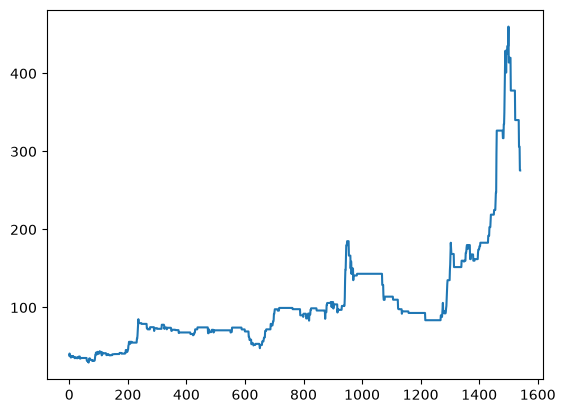

In [10]:
import matplotlib.pyplot as plt

plt.plot(bua['close_price'])
plt.show()

Lets take a closer look.

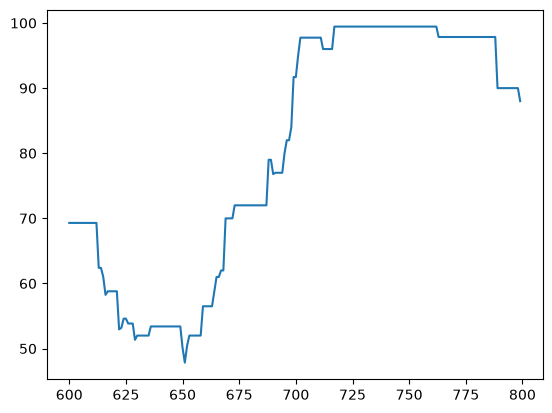

In [9]:
plt.plot(bua['close_price'][600:800])
plt.show()

We observe that the price can be steady over some days. Since we have started using monthly data. We will continue with it.

In [11]:
bua_end_month_df = (
    bua
    .sort_values("date")
    .groupby(bua["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

bua_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,115149,BUACEMENT,2020-01-31,37.00,37.00,1084368,2026-04-08T03:24:31.961868+00:00,1,1,2020
1,117209,BUACEMENT,2020-02-28,37.15,37.15,61653,2026-04-08T03:25:28.472167+00:00,2,1,2020
2,119372,BUACEMENT,2020-03-31,35.30,35.30,1278,2026-04-08T03:26:28.926506+00:00,3,1,2020
3,121432,BUACEMENT,2020-04-30,32.60,32.60,1413754,2026-04-08T03:27:25.479794+00:00,4,2,2020
4,122977,BUACEMENT,2020-05-29,42.00,42.00,816643,2026-04-08T03:28:14.796152+00:00,5,2,2020
...,...,...,...,...,...,...,...,...,...,...
74,35269,BUACEMENT,2026-03-31,326.70,326.70,405451,2026-03-31T15:00:02.085058+00:00,3,1,2026
75,281096,BUACEMENT,2026-04-30,418.00,418.00,1915439,2026-04-30T15:00:02.170664+00:00,4,2,2026
76,284162,BUACEMENT,2026-05-29,420.00,420.00,608687,2026-05-29T15:00:02.455558+00:00,5,2,2026
77,294090,BUACEMENT,2026-06-30,340.20,340.20,376282,2026-06-30T15:10:03.08168+00:00,6,2,2026


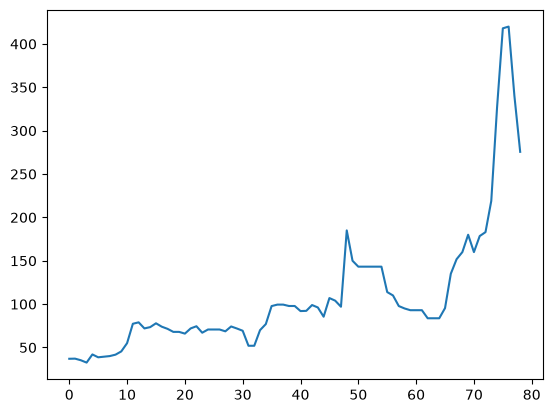

In [12]:
plt.plot(bua_end_month_df['close_price'])
plt.show()

In [13]:
bua_end_month_df['returns']=bua_end_month_df['close_price'].pct_change()*100
bua_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,115149,BUACEMENT,2020-01-31,37.00,37.00,1084368,2026-04-08T03:24:31.961868+00:00,1,1,2020,NaN
1,117209,BUACEMENT,2020-02-28,37.15,37.15,61653,2026-04-08T03:25:28.472167+00:00,2,1,2020,0.405405
2,119372,BUACEMENT,2020-03-31,35.30,35.30,1278,2026-04-08T03:26:28.926506+00:00,3,1,2020,-4.979812
3,121432,BUACEMENT,2020-04-30,32.60,32.60,1413754,2026-04-08T03:27:25.479794+00:00,4,2,2020,-7.648725
4,122977,BUACEMENT,2020-05-29,42.00,42.00,816643,2026-04-08T03:28:14.796152+00:00,5,2,2020,28.834356
...,...,...,...,...,...,...,...,...,...,...,...
74,35269,BUACEMENT,2026-03-31,326.70,326.70,405451,2026-03-31T15:00:02.085058+00:00,3,1,2026,49.178082
75,281096,BUACEMENT,2026-04-30,418.00,418.00,1915439,2026-04-30T15:00:02.170664+00:00,4,2,2026,27.946128
76,284162,BUACEMENT,2026-05-29,420.00,420.00,608687,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.478469
77,294090,BUACEMENT,2026-06-30,340.20,340.20,376282,2026-06-30T15:10:03.08168+00:00,6,2,2026,-19.000000


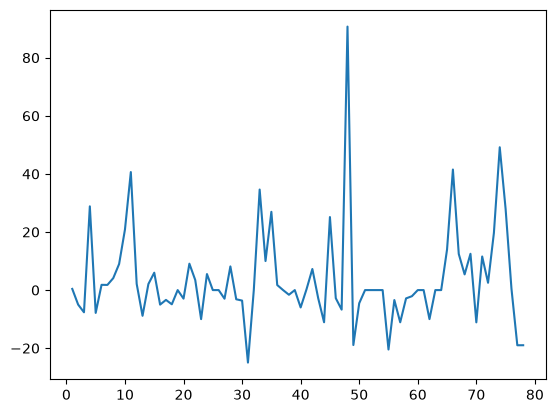

In [14]:
plt.plot(bua_end_month_df['returns'])
plt.show()

In [16]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(bua_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-7.988982342019577), np.float64(2.5040453746250664e-12), 0, 77, {'1%': np.float64(-3.518281134660583), '5%': np.float64(-2.899878185191432), '10%': np.float64(-2.5872229937594873)}, np.float64(558.5864587174049))
stationary


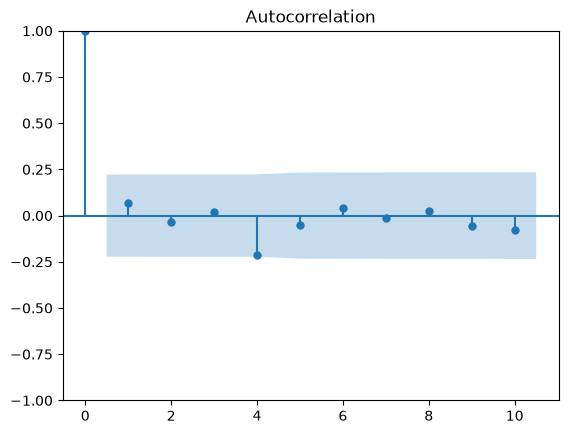

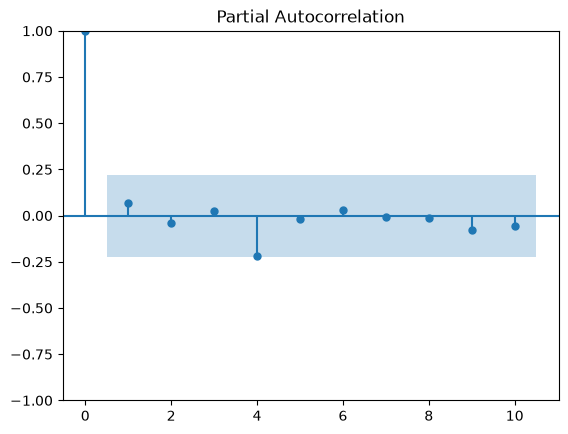

In [18]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(bua_end_month_df['returns'].dropna(), lags=10)
plot_pacf(bua_end_month_df['returns'].dropna(), lags=10)
plt.show()

We will have to use `GRID SEARCH` to find the optimal model. We will check yearly seasonality for monthly data (12). We will use close_price since it was a better when we trained with FCMB



In [19]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [20]:
train=bua_end_month_df['close_price'][:-10]
test=bua_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -7.988793089477012]
[0, 0, 0, 0, 0, 1, -6.915059525457969]
[0, 0, 0, 0, 0, 2, -7.263288907403835]
[0, 0, 0, 0, 1, 0, -3.4444230667307334]
[0, 0, 0, 0, 1, 1, -3.1605732169997314]
[0, 0, 0, 0, 1, 2, -1.8692088641824407]
[0, 0, 0, 0, 2, 0, -5.564266882638791]
[0, 0, 0, 0, 2, 1, -3.0530843271781594]
[0, 0, 0, 0, 2, 2, -2.06600516884393]
[0, 0, 0, 1, 0, 0, -3.7567281368253225]
[0, 0, 0, 1, 0, 1, -3.50041840389553]
[0, 0, 0, 1, 0, 2, -2.3204493820382406]
[0, 0, 0, 1, 1, 0, -2.975205163584058]
[0, 0, 0, 1, 1, 1, -2.942146963440451]
[0, 0, 0, 1, 1, 2, -1.9511307146140275]
[0, 0, 0, 1, 2, 0, -3.0835695278961337]
[0, 0, 0, 1, 2, 1, -1.8674029996339243]
[0, 0, 0, 1, 2, 2, -1.6084338498156616]
[0, 0, 0, 2, 0, 0, -3.375091292735336]
[0, 0, 0, 2, 0, 1, -3.342844800892512]
[0, 0, 0, 2, 0, 2, -2.408422893799368]
[0, 0, 0, 2, 1, 0, -2.8533945790821678]
[0, 0, 0, 2, 1, 1, -3.0748082527843703]
[0, 0, 0, 2, 1, 2, -2.6853816615115607]
[0, 0, 0, 2, 2, 0, -1.8775862189792583]
[0, 0, 0, 2, 

In [21]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
687,2,2,1,1,1,0,-202466.196787
417,1,2,0,1,1,0,-27611.090153
93,0,1,0,1,1,0,-1774.355561
728,2,2,2,2,2,2,-15.000509
444,1,2,1,1,1,0,-7.988793
...,...,...,...,...,...,...,...
667,2,2,0,2,0,1,0.512769
648,2,2,0,0,0,0,0.516616
649,2,2,0,0,0,1,0.517850
657,2,2,0,1,0,0,0.518255


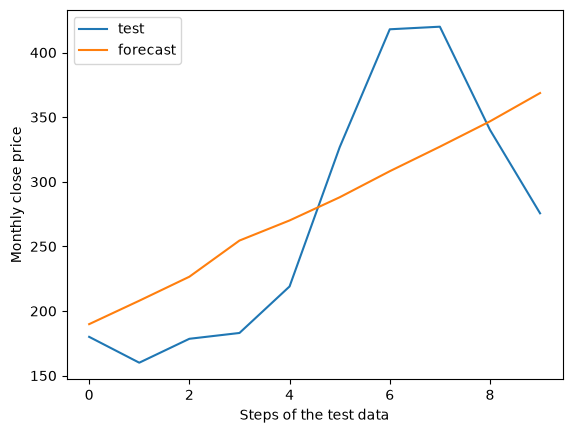

0.5257179243071886
65.81158548187457


In [ ]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=bua_end_month_df['close_price'][:-10]
y_test=bua_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(1,0,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print(r2_score(y_test, fcst))
print(np.sqrt(mean_squared_error(y_test,fcst)))

In [23]:
bua_end_month_df['close_price'].describe()

count     79.000000
mean     109.352532
std       77.093283
min       32.600000
25%       70.375000
50%       92.000000
75%      124.450000
max      420.000000
Name: close_price, dtype: float64

The RMSE is les than the STD meaning that the model is learning something. Although data points of 79 is still too small.